# Bibliotecas

In [35]:
# Importando pacotes

#Pacote matematica
import numpy as np 

# Pacote para trazer os dados da AER e econometria
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Pacote para manipulação de dataframes
import pandas as pd

# Pacote para visualização de graficos
import matplotlib.pyplot as plt

# Carregando as bases de dados

In [36]:
# Carregando base de dados

#Função para trazer as bases de dados e transformar em um dataFrame em pandas
def base_dados(nome_base):
    data_r = sm.datasets.get_rdataset(nome_base,  "AER")
    return data_r.data

# Atribuindo as bases de dados a uma variavel 
df_CASchools = base_dados("CASchools")
df_Cigarettes = base_dados("CigarettesB")
df_Fertility = base_dados("Fertility")
df_CreditCard = base_dados("CreditCard")
df_HousePrices = base_dados("HousePrices")
df_TravelMode = base_dados("TravelMode")

# 1. Conhecendo o pacote AER

## Exercício 1 - Exploração inicial
O pacote AER contém diversas bases de dados utilizadas em aplicações de econometria.

### 1. Liste as bases disponíveis no pacote AER.

In [37]:
#

### 2. Escolha cinco bases e descreva brevemente o fenômeno econômico analisado em cada uma

In [38]:
#

### 3. Para as bases CASchools, Cigarettes, Fertility, CreditCard, HousePrices e TravelMode, apresente o número de observções e de variáveis.


In [39]:
# Criando diccionario com as chavez contendo o nome da métrica e o valor ocontendo uma lista com valor que queremos (observações e núm de var.)
obs_var = {
    "núm. de observações":[
        len(df_CASchools),
        len(df_Cigarettes),
        len(df_Fertility),
        len(df_CreditCard),
        len(df_HousePrices),
        len(df_TravelMode)
    ],
    "núm. de variaveis":[
        len(df_CASchools.columns),
        len(df_Cigarettes.columns),
        len(df_Fertility.columns),
        len(df_CreditCard.columns),
        len(df_HousePrices.columns),
        len(df_TravelMode.columns)
    ]
}

# Transformando o diccionario em um dataframe que informa o número de observações e número de variaveis
df_obs_var = pd.DataFrame(
    obs_var,
    index = ["CASchools", "Cigarettes", "Fertility", "CreditCard", "HousePrices", "TravelMode"]
)

# Monstrando resultado (Resposta do exercício 1.3):
df_obs_var

,núm. de observações,núm. de variaveis
CASchools,420,14
Cigarettes,46,3
Fertility,254654,8
CreditCard,1319,12
HousePrices,546,12
TravelMode,840,9


### 4. Identifique, para cada base, quais variáveis poderiam ser utilizadas como variável dependente em um modelo econométrico.


#### Observando as variáveis de cada base de dados rapidamente:

In [40]:
df_CASchools.columns

''' As variaveis das notas: "english", "read", e "math" poderiam ser varáveis dependentes em um modelo que queira avaliar se existe uma relação
 emtre o nível de escolaridade e nível de renda.
'''

' As variaveis das notas: "english", "read", e "math" poderiam ser varáveis dependentes em um modelo que queira avaliar se existe uma relação\n emtre o nível de escolaridade e nível de renda.\n'

In [41]:
df_Cigarettes.columns

# A váriavel "pack" pode servir de váriael dependente para avaliar se existe alguma relação entre tabagismo e nível de renda 

Index(['packs', 'price', 'income'], dtype='str')

In [42]:
df_Fertility.columns

Index(['morekids', 'gender1', 'gender2', 'age', 'afam', 'hispanic', 'other',
       'work'],
      dtype='str')

In [43]:
df_CreditCard.columns
""" A variavel 'expenditure' pode ser depentende, para poder avaliar o impacto de uma politica nas despesas """

" A variavel 'expenditure' pode ser depentende, para poder avaliar o impacto de uma politica nas despesas "

In [44]:
df_HousePrices.columns
'''A váriavel price pode ser dependente em um modelo que queira ver se o preço do imovel aumenta dado localização, número de banheiros, etc.  '''

'A váriavel price pode ser dependente em um modelo que queira ver se o preço do imovel aumenta dado localização, número de banheiros, etc.  '

In [45]:
df_TravelMode.columns

Index(['individual', 'mode', 'choice', 'wait', 'vcost', 'travel', 'gcost',
       'income', 'size'],
      dtype='str')

In [46]:
df_TravelMode

,individual,mode,choice,wait,vcost,travel,gcost,income,size
0,1,air,no,69,59,100,70,35,1
1,1,train,no,34,31,372,71,35,1
2,1,bus,no,35,25,417,70,35,1
3,1,car,yes,0,10,180,30,35,1
4,2,air,no,64,58,68,68,30,2
...,...,...,...,...,...,...,...,...,...
835,209,car,yes,0,27,510,82,20,1
836,210,air,no,64,66,140,87,70,4
837,210,train,no,44,54,670,156,70,4
838,210,bus,no,53,33,664,134,70,4


# 2. CASchools - Educação e desempenho escolar
A base CASchools contém informações sobre escolas da calífornia.

## Exercício 2 - Estatística descritiva
Carregue a base:  
data(”CASchools”) head(CASchools) summary(CASchools)  
Considere o desempenho médio dos alunos como varíavel de interesse.

In [47]:
# Criando varíavel de desemmpnho medio dos alunos: (english + read + math)/3
df_CASchools["score"] = ( df_CASchools.math + df_CASchools.read ) / 2

In [48]:
# Observando as 3 primeiras linhas
df_CASchools.head(3)

,district,school,county,grades,students,teachers,calworks,lunch,computer,expenditure,income,english,read,math,score
0,75119,Sunol Glen Unified,Alameda,KK-08,195,10.900000,0.510200,2.040800,67,6384.911133,22.690001,0.000000,691.599976,690.000000,690.799988
1,61499,Manzanita Elementary,Butte,KK-08,240,11.150000,15.416700,47.916698,101,5099.380859,9.824000,4.583333,660.500000,661.900024,661.200012
2,61549,Thermalito Union Elementary,Butte,KK-08,1550,82.900002,55.032299,76.322601,169,5501.954590,8.978000,30.000002,636.299988,650.900024,643.600006


### 1. Apresente estatísticas descritivas para as principais variáveis.

In [49]:
df_CASchools.describe()

,district,students,teachers,calworks,lunch,computer,expenditure,income,english,read,math,score
count,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000
mean,67472.809524,2628.792857,129.067376,13.246042,44.705237,303.383333,5312.407541,15.316588,15.768155,654.970477,653.342619,654.156548
std,3466.994655,3913.104985,187.912679,11.454821,27.123381,441.341298,633.937053,7.225890,18.285927,20.107980,18.754202,19.053347
min,61382.000000,81.000000,4.850000,0.000000,0.000000,0.000000,3926.069580,5.335000,0.000000,604.500000,605.400024,605.550018
25%,64307.750000,379.000000,19.662499,4.395375,23.282200,46.000000,4906.180054,10.639000,1.940807,640.400024,639.375015,640.050003
50%,67760.500000,950.500000,48.564999,10.520450,41.750700,117.500000,5214.516602,13.727800,8.777634,655.750000,652.449982,654.449997
75%,70419.000000,3008.000000,146.350002,18.981350,66.864725,375.250000,5601.401367,17.629001,22.970003,668.725006,665.849991,666.662491
max,75440.000000,27176.000000,1429.000000,78.994202,100.000000,3324.000000,7711.506836,55.327999,85.539719,704.000000,709.500000,706.750000


### 2. Construa um histograma para a varável de desempenho.

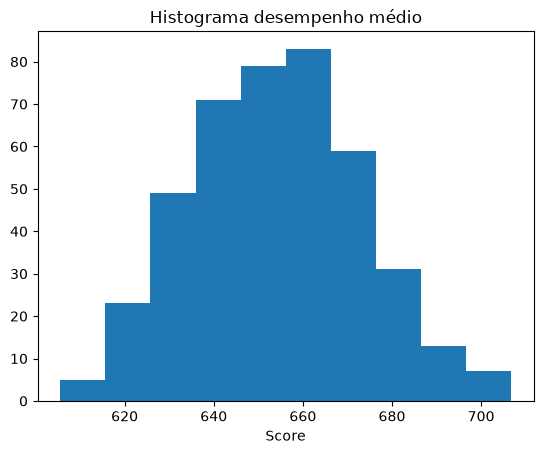

In [50]:
plt.hist(df_CASchools["score"])

plt.xlabel("Score")
plt.title("Histograma desempenho médio")

plt.show()

### 3. Construa um gráfico de dispersão entre desempenho e gasto por aluno.

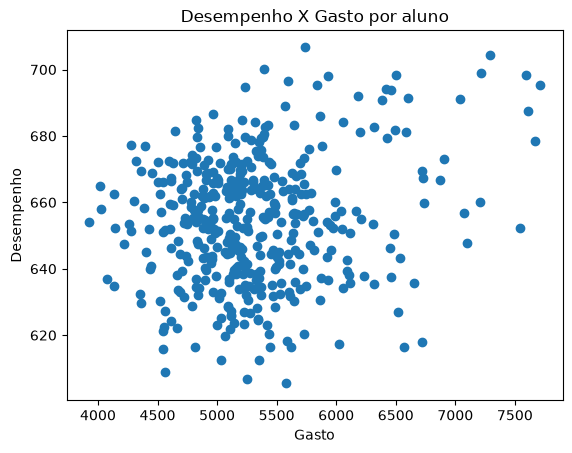

In [51]:
y = df_CASchools["score"]
x = df_CASchools["expenditure"]
plt.scatter(x, y)

plt.xlabel("Gasto")
plt.ylabel("Desempenho")
plt.title("Desempenho X Gasto por aluno")

plt.show()

### 4. Calcule a correlação entre essas duas variáveis.

In [52]:
# sendo y= Desempenho; e x= Gasto
x.corr(y)

np.float64(0.19127275899187818)

### 5. O gráfico sugere uma relação linear? Discuta  
>R: Oberva-se uma certa concentração de dados, entre 4500 e 5500. Porém, poderiamos dizer que sim, o gráfico sugere uma certa relação linear, >pois podemos observar que a dispersão dos dados mostra uma uma certa tendecia positiva linear a medida que a renda aumenta.

## Exercício 3 - Regressão linear simples
Estime um modelo de regressão linear simples no qual o desempenho escolar seja explicado pelo gasto por aluno:  
$$
\text{score}_i = \beta_0 + \beta_1 \text{expenditure}_i + u_i
$$

### 1. Estime o modelo 

In [53]:
modelo_linear = smf.ols("score ~ expenditure", data = df_CASchools).fit()

### 2. Apresente os resultados da regressão


In [54]:
modelo_linear.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  score   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     15.87
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           7.99e-05
Time:                        15:58:20   Log-Likelihood:                -1825.5
No. Observations:                 420   AIC:                             3655.
Df Residuals:                     418   BIC:                             3663.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     623.6165      7.720     80.783      0.000     608.442     638.791
expenditure     0.0057      0.001      3.984      0.000       0.003       0.009
==============================================================================
Omnibus:                        6.132   Durbin-Watson:                   0.111
Prob(Omnibus):                  0.047   Jarque-Bera (JB):                4.138
Skew:                          -0.075   Prob(JB):                        0.126
Kurtosis:                       2.538   Cond. No.                     4.52e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.52e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### 3. Interprete economicamente do $ \hat{\beta_1} $

>R: O coeficiente estimado $ \hat{\beta_1} $ = 0.0057 mede o efeito marginal do gasto por aluno sobre o desempenho escolar. O aumento de $1 na despesa por aluno está associado a um incremento médio de 0.0057 pontos na nota dos alunos.



### 4. Teste a hipótese de que o efeito do gasto sobre o desempenho é estatisticamente igual a zero.

$$
\begin{cases} 
H_0: \beta_1 = 0 & \text{(o gasto não afeta o desempenho)} \\ 
H_1: \beta_1 \neq 0 & \text{(o gasto afeta o desempenho)} 
\end{cases}
$$

A partir do modelo estimado via MQO:
* **Coeficiente estimado ($\hat{\beta}_1$):** $0{,}0057$
* **Erro-padrão ($SE$):** $0{,}001$
* **Estatística $t$:** $t = 3{,}984$
* **$p$-valor:** $P > |t| = 0{,}000$ ($p < 0{,}001$)

**Conclusão:** 
A um nível de significância de 5%, o $p$-valor < 0.001 , **rejeita-se a hipótese nula $H_0$**. 

Portanto, o efeito do gasto por aluno sobre o desempenho escolar é **estatisticamente significante** e diferente de zero.

### 5. Construa um intervalo de confiança de 95% para $ \beta_1 $

O intervalo de confiança de 95% para o parâmetro $\beta_1$ é dado por $[0{,}003 \ ; \ 0{,}009]$.   Interpretação: Com $95\%$ de confiança, estima-se que o verdadeiro efeito marginal do gasto por aluno sobre a nota média das escolas esteja entre $0{,}003$ e $0{,}009$ pontos por dólar investido. Como o intervalo não inclui o valor zero, reforça-se a conclusão de que o gasto possui um efeito positivo e estatisticamente significante sobre o desempenho escolar.   

### 6. Qual é o valor previsto do desempenho para uma escola cujo gasto por aluno seja igual á média da amostra?

In [55]:
# Média da variável despesa
media_expenditure = df_CASchools["expenditure"].mean()

# Valor previsto do desempenho ao imputar o gasto medio por aluno 
score_previsto = modelo_linear.params['Intercept'] + modelo_linear.params["expenditure"] * media_expenditure

# Resposta:
print(f"Gasto médio: {media_expenditure:.2f}")
print(f"Desempenho previsto: {score_previsto:.2f}")

Gasto médio: 5312.41
Desempenho previsto: 654.16


## Exercício 4 - Regressão múltipla
Estime o modelo que inclua, além do gasto por aluno, a proporção de alunos que possuem inglês como segunda língua e a renda média da região.
$$
score_{i} = \beta_0 + \beta_1 expenditure_{i} + \beta_2 english_{i} + \beta_3 income_{i} + u_{i}
$$

### 1. Estime o modelo

In [56]:
modelo_multiplo = smf.ols("score ~ expenditure + english + income ", data = df_CASchools).fit()
modelo_multiplo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  score   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                     335.6
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          1.13e-110
Time:                        15:58:20   Log-Likelihood:                -1575.1
No. Observations:                 420   AIC:                             3158.
Df Residuals:                     416   BIC:                             3174.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     642.3197      4.327    148.447      0.000     633.814     650.825
expenditure    -0.0007      0.001     -0.831      0.406      -0.002       0.001
english        -0.4885      0.029    -16.821      0.000      -0.546      -0.431
income          1.5178      0.077     19.655      0.000       1.366       1.670
==============================================================================
Omnibus:                        4.295   Durbin-Watson:                   1.204
Prob(Omnibus):                  0.117   Jarque-Bera (JB):                4.242
Skew:                          -0.176   Prob(JB):                        0.120
Kurtosis:                       3.344   Cond. No.                     4.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### 2. Compare os coeficientes obtidos com aqueles do modelo simples.

In [57]:
# Criando tabela comparativa de estimadores entre a regressã mutipla e simples
estimadores = {
    "regressão linear": 
    [
        modelo_linear.params["expenditure"],
        None,
        None
    ],
    "regressão multipla":
    [
        modelo_multiplo.params["expenditure"],
        modelo_multiplo.params["english"],
        modelo_multiplo.params["income"]
    ]
}


tab_estimadores = pd.DataFrame(estimadores, index = ['expenditure(B1)', 'english(B2)', 'income(b3)'])

In [58]:
tab_estimadores

,regressão linear,regressão multipla
expenditure(B1),0.005749,-0.000698
english(B2),NaN,-0.488505
income(b3),NaN,1.517766


>R: Observa-se que o parametro $ \beta_1 $ mudou de sinal. Enquanto na regressão simples a relação entre despesa por aluno e desempenho era positiva, na regressão multiplica essa relação agora é negativa.

### 3. Explique por que o coeficiente do gasto por aluno pode mudar após a inclusão de novas variáveis.

>R:  Na regressão simples, as variaveis income e english, estavama omitidas. Como distritos de maior renda média tendem a gastar mais por alunos, e ao mesmo tempo apresentam notas médias mais elevadas, o modelo simples atribuiu erroneamente ao gasto por aluno o eveito positivo que na verdade pertencia à renda das familias, o que gerou um viés positivo no coeficiente $\hat{\beta_1}$

### 4. Avalie a significância estatística individual dos coeficientes.

In [59]:
p_valores = {
    "p-valor":[
        f"{modelo_multiplo.pvalues["expenditure"]:.2f}",
        modelo_multiplo.pvalues["english"],
        modelo_multiplo.pvalues["income"]
    ],
    "Rejeita H0 (p < 0,05)":[
        "SIM " if modelo_multiplo.pvalues["expenditure"] < 0.05 else "NAO",
        "SIM " if modelo_multiplo.pvalues["english"] < 0.05 else "NAO",
        "SIM " if modelo_multiplo.pvalues["income"] < 0.05 else "NAO"
    ]
}

tab_pvalores = pd.DataFrame(p_valores, index = ["expenditure", "english", "income"])

In [60]:
tab_pvalores

,p-valor,"Rejeita H0 (p < 0,05)"
expenditure,0.41,NAO
english,0.0,SIM
income,0.0,SIM


>R: A 5% de significância, o gasto deixa de ser estatisticamente significativo, enquanto english e income são significativos

### 5. Interprete o $R^2$ e o $R^2$ ajustado 

>$R^2$ = 0.708 significa que aproximadamente 70,8% da variação no desempenho escolar dos alunos é explicada pelas variáveis do modelo, e os 29,2% restantes são fatores não observados contidos no termo de erro.
>O $R^2$ ajustado = 0,706 penaliza a inclusão de variáveis explicativas adicionais de acordo com os graus de liberdade. Ele ajusta a capacidade de explicaçção ao número de regressores e ao tamanho da amostra.

# 3 Cigarettes - Preços, impostos e consumo

## Exercício 5 - Relação entre preço e consumo

### 1. Carregue a base Cigarrettes.

In [61]:
cigarettes = df_Cigarettes

### 2. Identifique a variável que represente o consumo de cigarros e a variável relacionada ao preço

In [62]:
cigarettes.columns

Index(['packs', 'price', 'income'], dtype='str')

>R: São, respectivamente: 'packs' e 'price'

### 3. Construa um gráfico de dispersão entre peço e consumo

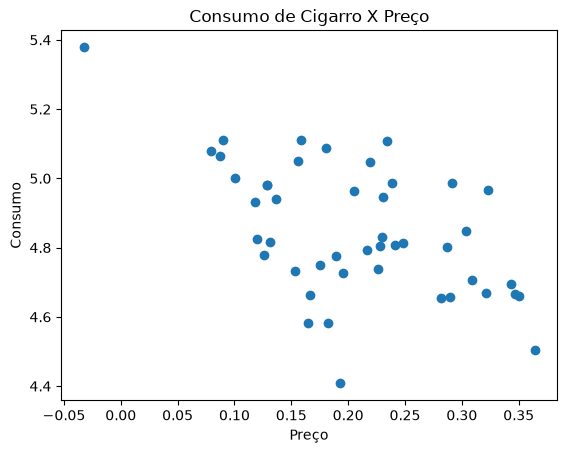

In [63]:
# Criando gráfico
plt.scatter(cigarettes.price, cigarettes.packs)

# Dando nome aos labels
plt.xlabel("Preço")
plt.ylabel("Consumo")
plt.title("Consumo de Cigarro X Preço")

# Monstrando gráfico
plt.show()

### 4. Estime uma regressão lineaR simples do consumo sobre o preço

In [64]:
m_linear_cigarrete = smf.ols("packs ~ price", data= cigarettes).fit()
m_linear_cigarrete.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  packs   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     18.08
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           0.000108
Time:                        15:58:21   Log-Likelihood:                 19.195
No. Observations:                  46   AIC:                            -34.39
Df Residuals:                      44   BIC:                            -30.73
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.0941      0.063     81.247      0.000       4.968       5.220
price         -1.1983      0.282     -4.253      0.000      -1.766      -0.630
==============================================================================
Omnibus:                        1.860   Durbin-Watson:                   2.307
Prob(Omnibus):                  0.395   Jarque-Bera (JB):                1.209
Skew:                          -0.389   Prob(JB):                        0.546
Kurtosis:                       3.164   Cond. No.                         12.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 5. O sinal estimado para o preço é compatível com a teoria econômica? Explique.

>R: O valor estimado para 'price' foi de -1,19. Sim, é compatível com a teoria da demanda, onde demanda e preço são inversamente proporcional.

## Exercício 6 - Elasticidade - preço
Considere um modelo log-log:
$$
ln(consumption_{i}) = \beta_0 + \beta_1 ln(price_{i}) + u_{i}
$$

### 1. Estime o modelo

In [65]:
# Criando o ln das duas variaveis dentro da base de dados
cigarettes["ln_packs"] = np.log(cigarettes["packs"])
cigarettes["ln_price"] = np.log(cigarettes["price"])

c:\Users\Usuario\Desktop\PPGE 2s\Econometria\Atividades\Atividade 2\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [66]:
#Estimando modelo
m_linear_ln_cigarrete = smf.ols("ln_packs ~ ln_price", data= cigarettes).fit()
m_linear_ln_cigarrete.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               ln_packs   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     11.28
Date:                Sun, 20 Sep 2026   Prob (F-statistic):            0.00165
Time:                        15:58:21   Log-Likelihood:                 90.828
No. Observations:                  45   AIC:                            -177.7
Df Residuals:                      43   BIC:                            -174.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.5084      0.021     73.391      0.000       1.467       1.550
ln_price      -0.0411      0.012     -3.358      0.002      -0.066      -0.016
==============================================================================
Omnibus:                        1.618   Durbin-Watson:                   2.385
Prob(Omnibus):                  0.445   Jarque-Bera (JB):                0.948
Skew:                          -0.339   Prob(JB):                        0.623
Kurtosis:                       3.212   Cond. No.                         9.43
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 2. Interprete o $\beta_1$ como uma elasticidade

>R: O coeficiente estimado $\beta_1$ = -,0411 representa a elasticidade preço da demanda. Significa que um aumento de 1% no preço do cigarro está associado a uma redução média de aproximadamente 0,0411% no consumo de cigarro. Como o valor absoluto do parametro é menor que 1, podemos falar que a demanda por cigarros é inelástica em relação ao preço.

### 3. Compare o resultado com o modelo em nível.

>R: No modelo em nível, o coeficiente mede a variação em unidades consumidas por 1 dólar no preço, o que depende da unidade de medida das variáveos, já no modelo log-log, o coeficiente independe das unidades de medida (dólares por exemplo).

#### 4. Qual especificação apresenta uma interpretação econômica mais conveniente para medir a resposta do consumo ao preço?

>R: Do ponto de vista econômico, o modelo log-log é mais conveniente, pois ele nos diz a intensidade com a qual o preço afeta o consumo, ou olhando por outra perspectiva, ele nos diz a sensibilidade da demanda à variações do preço.

# Fertility - Fertilidade e participação feminina
A base Fertility permite analisar fatores associados à fertilidade e à participação das mulheres no mercado de trabalho.

## Exercício 7 - Modelo de regressão
Considere a seguinte especificação:
$$
children_{i} = \beta_0 + \beta_1 work_{1} + \beta_2 age_{i} + \beta_3 education_{i} + u_{i}
$$

### 1. Estime o modelo

In [67]:
# rescrevendo o nome da base
fertility = df_Fertility

In [68]:
# Estimando o modelo
#modelo_fertility = smf.ols("morekids ~ work + age + afam", data = fertility)

In [69]:
fertility.head(3)

,morekids,gender1,gender2,age,afam,hispanic,other,work
0,no,male,female,27,no,no,no,0
1,no,female,male,30,no,no,no,30
2,no,male,female,27,no,no,no,0


# 5 CreditCard - Aprovação de crédito
Contém informações relacionada à utilização e aprovação de cartões de crédito.

## Exercício 9 - Variáveis qualitativas
Identifique a variável que representa a aprovação ou aceitação do cartão.

### 1 Verifique como a variável dependente está codificada.

In [70]:
# Renomeando a base de dados
credit_card = df_CreditCard

In [71]:
# Visualizaçã rapida da base de dados
credit_card.head(3)

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0,37.66667,4.52,0.033270,124.983300,yes,no,3,54,1,12
1,yes,0,33.25000,2.42,0.005217,9.854167,no,no,3,34,1,13
2,yes,0,33.66667,4.50,0.004156,15.000000,yes,no,4,58,1,5


>R: A variável que representa a aprovação ou aceite do cartão é "card". Ela é a variável dependente. É uma varíavel categórica binária assumindo "yes" (para cartão aprovado) e "no" (para catão recusado). 

### 2. Estime um modelo de probabilidade linear
### 3. Escolha varáveis explicativas relacioadas à renda, idade e características financeiras do indivíduo.

In [72]:
# Transoformando card em variavel binaria
credit_card["card_binary"] = (credit_card["card"] == "yes").astype(int) 

In [73]:
# Estimando modelo de probabilidade linear
mpl_credit = smf.ols("card_binary ~ income + age + reports + share", data=credit_card).fit()
mpl_credit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            card_binary   R-squared:                       0.321
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     155.5
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          5.55e-109
Time:                        15:58:21   Log-Likelihood:                -462.91
No. Observations:                1319   AIC:                             935.8
Df Residuals:                    1314   BIC:                             961.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6118      0.036     17.179      0.000       0.542       0.682
income         0.0271      0.006      4.578      0.000       0.015       0.039
age            0.0009      0.001      0.869      0.385      -0.001       0.003
reports       -0.1247      0.007    -17.450      0.000      -0.139      -0.111
share          1.4663      0.102     14.356      0.000       1.266       1.667
==============================================================================
Omnibus:                      194.783   Durbin-Watson:                   1.877
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              290.405
Skew:                          -1.148   Prob(JB):                     8.70e-64
Kurtosis:                       3.103   Cond. No.                         379.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 4. Interprete os coeficientes como variações na probabilidade

>R: Os coeficientes estimados representam variações diretas na probabilidade marginal de aprovação do cartão (Y=1).
* income: O aumento de 1000 dolares na renda anual do indivíduo está associado a um aumento de 2,71% na probabilidade de ter o crédito aprovado. O efeito é estatisticamente significante (p = 0,000)
* age: Cada ano adicional de idade aumenta a probabilidade de aprovação do cartão em 0,09%. O efeito não é estatisticamente significante (p = 0,385).
* reports: Cada reporte adicional no histórico financeiro do indivíduo está associado a uma redução de 12,47 pontos percentuais. O efeito é significante (p-0,000).
* share: Um aumento de 1 unidade na proporção de gastos em cartão em relação á renda aumenta a probabilidade de aprovação em 145,63 pontos perncetuais.

### 5. Identifique as principais limitações do modelo de probabilidade linear

>R: O MQO assume uma relação linear irrestrita, logo, acabamos obtendo probabilidades previstas fora do intervalo [0,1], que é o que acontece com a varíavel share, ou seja, obtemos uma probabilidade superior à 100%. Logo, seria melhor utilizar um modelo alternativo ao modelo linear.

# 6 HousePrices - Mercado imobiliário
Permite estudar os determinantes dos preços dos imóveis

## Exercício 10 = Determinantes dos preços dos imóveis
Estime um modelo do tipo:
$$
price_{i} = \beta_0 + \beta_1 size_{i} + \beta_2 bedrooms_{i} + \beta_3 bathrooms+{i} + u_{i}
$$

### Estime o modelo por MQO.

In [74]:
# Renomeando nome da base
house = df_HousePrices

In [75]:
modelo_house = smf.ols("price ~ lotsize + bedrooms + bathrooms", data = house).fit()
modelo_house.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.486
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     171.0
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           5.22e-78
Time:                        15:58:21   Log-Likelihood:                -6157.5
No. Observations:                 546   AIC:                         1.232e+04
Df Residuals:                     542   BIC:                         1.234e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -2418.2926   3779.412     -0.640      0.523   -9842.383    5005.798
lotsize        5.4112      0.388     13.947      0.000       4.649       6.173
bedrooms    5826.8024   1206.571      4.829      0.000    3456.675    8196.930
bathrooms   1.975e+04   1785.083     11.064      0.000    1.62e+04    2.33e+04
==============================================================================
Omnibus:                       69.878   Durbin-Watson:                   1.394
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              141.218
Skew:                           0.734   Prob(JB):                     2.16e-31
Kurtosis:                       5.014   Cond. No.                     2.64e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.64e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### 2. Interprete os coeficiente.

>R: 
>* lotsize ($\hat{\beta_1}$ = 5,41): Cada pé quadrado adicional na área do lote está associado a um aumento médio de US$ 5,41 no preço do imóvel.
>* bedrooms ($\hat{\beta_2}$ = 5826,8): Adicionar um quarto à residência está associado a uma elevação média de US$ 5826,80 no preço do imóvel.
>* bathrooms ($\hat{\beta_3}$ = 19752): A cada banheiro adicional que uma casa possua, á um aumento médio associado de $US 19752 no preço. 

### 3. Qual variável apresenta maior associação com o preço?

### 4. Teste a significância conjunta das variáveis relacionadas ao tamanho do imóvel.

$$
\begin{cases} 
H_0: \beta_1 = \beta_2 = \beta_3 = 0 & \text{(as varáveis não possuem efeito conjunto/modelo não significante)} \\ 
H_1: Pelo menos um dos coeficientes \beta_{j} \neq 0  & \text{(As variáveis são conjuntamente significantes)} 
\end{cases}
$$

>R: Como o p-valor associado à estatística F é extremadamente próximo de zero (Prob (F-statistic):	5.22e-78), rejeitamos a hipótese nula ao nível de significância de 1%. Concluimos que as variáveis explicativas do modelo são conjuntamente estatisticamente significantes para explicar os preços das residências.

### 5. Discuta a possibilidade de multicolinearidade.


## Exercício 11 - Transformações 
Estime uma especificação log-log:
$$
ln(price_{i}) = \beta_0 + \beta_1 ln(size_{1}) + \beta_2 bedrooms_{i} + \beta_3 bathrooms_{i} + u_{i}
$$

### 1. Estime o modelo

In [76]:
# Crindo e adicionando os ln das variaveis 
house["ln_price"] = np.log(house["price"])
house["ln_lotsize"] = np.log(house["lotsize"])

In [77]:
# Estimando o modelo
modelo_ln_house = smf.ols("ln_price ~ ln_lotsize + bedrooms + bathrooms", data = house).fit()
modelo_ln_house.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               ln_price   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     183.4
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           4.53e-82
Time:                        15:58:21   Log-Likelihood:                -43.015
No. Observations:                 546   AIC:                             94.03
Df Residuals:                     542   BIC:                             111.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.6222      0.241     27.451      0.000       6.148       7.096
ln_lotsize     0.4568      0.029     15.762      0.000       0.400       0.514
bedrooms       0.0892      0.017      5.404      0.000       0.057       0.122
bathrooms      0.2368      0.024      9.672      0.000       0.189       0.285
==============================================================================
Omnibus:                        4.038   Durbin-Watson:                   1.324
Prob(Omnibus):                  0.133   Jarque-Bera (JB):                3.887
Skew:                          -0.203   Prob(JB):                        0.143
Kurtosis:                       3.074   Cond. No.                         197.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 2. interprete $\beta_1$.

>R: O coeficiente estimado de 0,4568 representa a elasticidade-tamanho do preço do imóvel.  Como ambas variaveis estão em ln, o parâmetro mede a variação percentual esperada no preço dada uma variação percentual na área do terreno. Um aumento de 1% do tamanho do lote está associado a um aumento médio de aproximadamente de 0,46% no preço do imóvel

### 3. Compare os resultados com o modelo em nível


In [83]:
parametros_house = {
    "lin-lin":[
        modelo_house.params["lotsize"],
        modelo_house.params["bedrooms"],
        modelo_house.params["bathrooms"]
    ],
    "log-log":[
        modelo_ln_house.params["ln_lotsize"],
        modelo_ln_house.params["bedrooms"],
        modelo_ln_house.params["bathrooms"]
    ]
}

tab_params_house = pd.DataFrame(parametros_house, index = ["size", "bedrooms","bathrooms"])
tab_params_house

,lin-lin,log-log
size,5.411200,0.456821
bedrooms,5826.802411,0.089237
bathrooms,19750.210134,0.236758


>R: No modelo nível, os impactos são expressos em valores fixos de dólares. No modelo com log, o efeito passa a ser relativo (percentual). O tamanho deixa de ter um impacto fixo constante, e passa a refletir a elasticidade-preço do tamanho. Em ambos modelos, o impacto marginal do número de banheiros é muito superior comparado ao efeito marginal ocasionado pelo número de quartos na determinação dos preços dos imóveis.

### 4. Qual modelo você considera mais adequado?